## JAIZBANK STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

jaizbank=pd.read_csv('../stock_data/jaizbank.csv') ## so it can be small letter. This is cool.
jaizbank=jaizbank.drop(columns=['high_price','low_price'])
jaizbank.rename(columns={'trade_date':'date'},inplace=True)
jaizbank['date']=pd.to_datetime(jaizbank['date'])
jaizbank['month']=jaizbank['date'].dt.month
jaizbank['quarter']=jaizbank['date'].dt.quarter
jaizbank['year']=jaizbank['date'].dt.year

jaizbank

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,46109,JAIZBANK,2017-02-09,1.25,1.25,356000,2026-04-08T02:43:16.408746+00:00,2,1,2017
1,46220,JAIZBANK,2017-02-10,1.31,1.31,1278395,2026-04-08T02:43:18.597686+00:00,2,1,2017
2,46312,JAIZBANK,2017-02-13,1.31,1.31,1068883,2026-04-08T02:43:22.775561+00:00,2,1,2017
3,46424,JAIZBANK,2017-02-14,1.31,1.31,549617,2026-04-08T02:43:24.286485+00:00,2,1,2017
4,46536,JAIZBANK,2017-02-15,1.31,1.31,1081695,2026-04-08T02:43:26.422065+00:00,2,1,2017
...,...,...,...,...,...,...,...,...,...,...
2231,298078,JAIZBANK,2026-07-13,8.90,8.90,16076059,2026-07-13T15:10:02.995074+00:00,7,3,2026
2232,298516,JAIZBANK,2026-07-14,8.85,8.85,8265761,2026-07-14T15:10:03.094441+00:00,7,3,2026
2233,298954,JAIZBANK,2026-07-15,8.60,8.60,13645929,2026-07-15T15:10:03.078609+00:00,7,3,2026
2234,299392,JAIZBANK,2026-07-16,8.95,8.95,9122062,2026-07-16T15:10:03.113936+00:00,7,3,2026


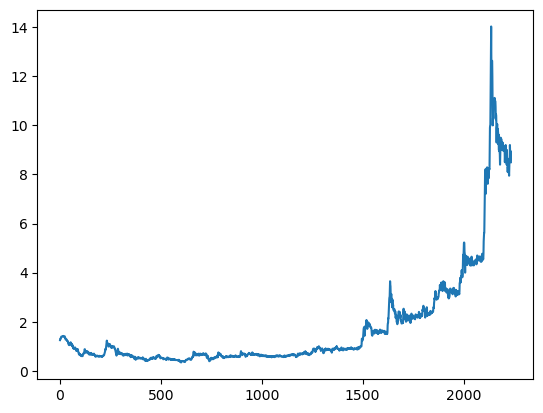

In [2]:
import matplotlib.pyplot as plt

plt.plot(jaizbank['close_price'])
plt.show()

In [3]:
jaizbank_end_month_df = (
    jaizbank
    .sort_values("date")
    .groupby(jaizbank["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

jaizbank_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,47200,JAIZBANK,2017-02-28,1.40,1.40,250000,2026-04-08T02:44:45.006295+00:00,2,1,2017
1,49316,JAIZBANK,2017-03-31,1.21,1.21,610,2026-04-08T02:45:42.281198+00:00,3,1,2017
2,51144,JAIZBANK,2017-04-28,1.15,1.15,19986792,2026-04-08T02:51:55.619599+00:00,4,2,2017
3,53066,JAIZBANK,2017-05-31,0.95,0.95,1350,2026-04-08T02:52:57.421655+00:00,5,2,2017
4,54906,JAIZBANK,2017-06-30,0.70,0.70,4597902,2026-04-08T02:53:53.827964+00:00,6,2,2017
...,...,...,...,...,...,...,...,...,...,...
109,35315,JAIZBANK,2026-03-31,10.00,10.00,12872679,2026-03-31T15:00:02.085058+00:00,3,1,2026
110,281141,JAIZBANK,2026-04-30,9.40,9.40,25550011,2026-04-30T15:00:02.170664+00:00,4,2,2026
111,284207,JAIZBANK,2026-05-29,8.97,8.97,8958405,2026-05-29T15:00:02.455558+00:00,5,2,2026
112,294135,JAIZBANK,2026-06-30,8.30,8.30,11152355,2026-06-30T15:10:03.08168+00:00,6,2,2026


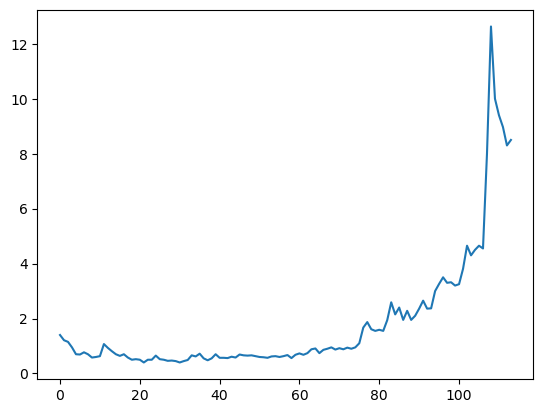

In [4]:
plt.plot(jaizbank_end_month_df['close_price'])
plt.show()

In [5]:
jaizbank_end_month_df['returns']=jaizbank_end_month_df['close_price'].pct_change()*100
jaizbank_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,47200,JAIZBANK,2017-02-28,1.40,1.40,250000,2026-04-08T02:44:45.006295+00:00,2,1,2017,NaN
1,49316,JAIZBANK,2017-03-31,1.21,1.21,610,2026-04-08T02:45:42.281198+00:00,3,1,2017,-13.571429
2,51144,JAIZBANK,2017-04-28,1.15,1.15,19986792,2026-04-08T02:51:55.619599+00:00,4,2,2017,-4.958678
3,53066,JAIZBANK,2017-05-31,0.95,0.95,1350,2026-04-08T02:52:57.421655+00:00,5,2,2017,-17.391304
4,54906,JAIZBANK,2017-06-30,0.70,0.70,4597902,2026-04-08T02:53:53.827964+00:00,6,2,2017,-26.315789
...,...,...,...,...,...,...,...,...,...,...,...
109,35315,JAIZBANK,2026-03-31,10.00,10.00,12872679,2026-03-31T15:00:02.085058+00:00,3,1,2026,-20.823436
110,281141,JAIZBANK,2026-04-30,9.40,9.40,25550011,2026-04-30T15:00:02.170664+00:00,4,2,2026,-6.000000
111,284207,JAIZBANK,2026-05-29,8.97,8.97,8958405,2026-05-29T15:00:02.455558+00:00,5,2,2026,-4.574468
112,294135,JAIZBANK,2026-06-30,8.30,8.30,11152355,2026-06-30T15:10:03.08168+00:00,6,2,2026,-7.469342


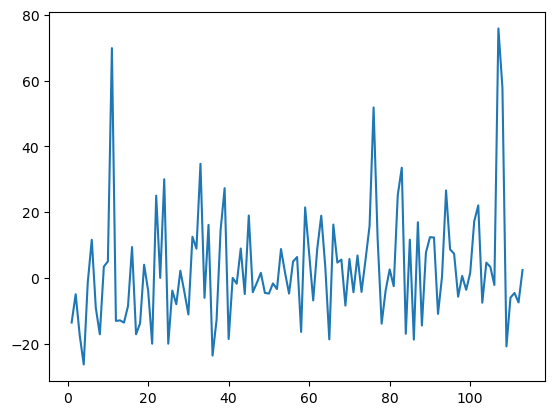

In [6]:
plt.plot(jaizbank_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(jaizbank_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-10.056085229909495, 1.3719178215298889e-17, 0, 112, {'1%': -3.4901313156261384, '5%': -2.8877122815688776, '10%': -2.5807296460459184}, 838.992012964057)
stationary


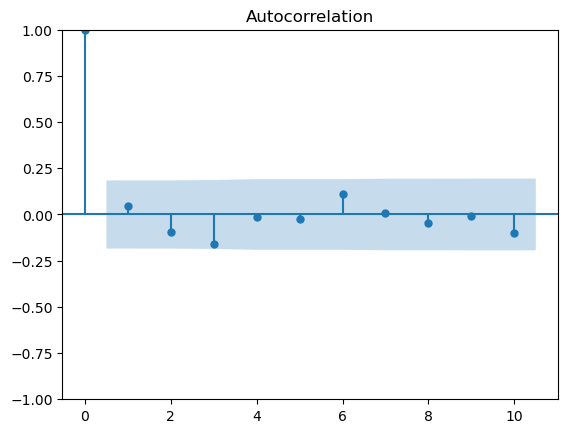

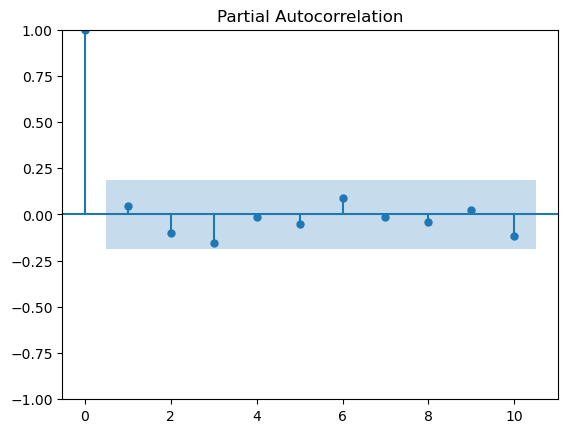

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(jaizbank_end_month_df['returns'].dropna(), lags=10)
plot_pacf(jaizbank_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=jaizbank_end_month_df['close_price'][:-10]
test=jaizbank_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -9.871102864693148]
[0, 0, 0, 0, 0, 1, -6.027384269520455]
[0, 0, 0, 0, 0, 2, -4.315514863843125]
[0, 0, 0, 0, 1, 0, -3.3832975676190653]
[0, 0, 0, 0, 1, 1, -2.8667644685474665]
[0, 0, 0, 0, 1, 2, -2.3562313782382214]
[0, 0, 0, 0, 2, 0, -1.8679948397472477]
[0, 0, 0, 0, 2, 1, -1.9076442849503348]
[0, 0, 0, 0, 2, 2, -1.6497285668869819]
[0, 0, 0, 1, 0, 0, -3.5912740424622225]
[0, 0, 0, 1, 0, 1, -3.068874567890618]
[0, 0, 0, 1, 0, 2, -2.5749007813995357]
[0, 0, 0, 1, 1, 0, -2.209424441782772]
[0, 0, 0, 1, 1, 1, -2.183123768091688]
[0, 0, 0, 1, 1, 2, -1.985961026339611]
[0, 0, 0, 1, 2, 0, -1.8924586653812407]
[0, 0, 0, 1, 2, 1, -1.8149781076122538]
[0, 0, 0, 1, 2, 2, -1.6740879841646823]
[0, 0, 0, 2, 0, 0, -2.512107897471347]
[0, 0, 0, 2, 0, 1, -2.507934564830199]
[0, 0, 0, 2, 0, 2, -2.343260046080144]
[0, 0, 0, 2, 1, 0, -2.1586526747989123]
[0, 0, 0, 2, 1, 1, -2.091917009558551]
[0, 0, 0, 2, 1, 2, -2.016515236191133]
[0, 0, 0, 2, 2, 0, -1.6414449524888926]
[0, 0, 0, 2,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-13.378328
0,0,0,0,0,0,0,-9.871103
27,0,0,1,0,0,0,-9.664489
54,0,0,2,0,0,0,-9.555440
169,0,2,0,0,2,1,-8.475596
...,...,...,...,...,...,...,...
668,2,2,0,2,1,1,-0.459139
654,2,2,0,0,2,2,-0.439485
667,2,2,0,2,1,0,-0.430271
672,2,2,0,2,2,2,-0.403803


Not good enough. Lets try the returns.

In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=jaizbank_end_month_df['returns'].dropna()[:-10]
test=jaizbank_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.1231708881817517]
[0, 0, 0, 0, 0, 1, -0.13053413985649476]
[0, 0, 0, 0, 0, 2, -0.10384299934320906]
[0, 0, 0, 0, 1, 0, -0.010102642846634202]
[0, 0, 0, 0, 1, 1, 0.16120312799130176]
[0, 0, 0, 0, 1, 2, 0.12582523260983347]
[0, 0, 0, 0, 2, 0, -0.5290032075047428]
[0, 0, 0, 0, 2, 1, -0.1632877412803757]
[0, 0, 0, 0, 2, 2, -0.08213646394248375]
[0, 0, 0, 1, 0, 0, -0.1316830096991357]
[0, 0, 0, 1, 0, 1, -0.0722693470187925]
[0, 0, 0, 1, 0, 2, -0.02020694226072184]
[0, 0, 0, 1, 1, 0, -0.011830119342844947]
[0, 0, 0, 1, 1, 1, 0.121661127752696]
[0, 0, 0, 1, 1, 2, 0.1816179092624598]
[0, 0, 0, 1, 2, 0, -0.24151204362826006]
[0, 0, 0, 1, 2, 1, -0.1614947246245817]
[0, 0, 0, 1, 2, 2, -0.07439446746874179]
[0, 0, 0, 2, 0, 0, -0.09424062163383562]
[0, 0, 0, 2, 0, 1, -0.031992129942501]
[0, 0, 0, 2, 0, 2, 0.03870827654004183]
[0, 0, 0, 2, 1, 0, -0.025016577744656043]
[0, 0, 0, 2, 1, 1, 0.1567156412422076]
[0, 0, 0, 2, 1, 2, 0.1846890021648543]
[0, 0, 0, 2, 2, 0, -0.34164335386

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
176,0,2,0,1,2,0,-110.480970
185,0,2,0,2,2,0,-107.409709
177,0,2,0,1,2,1,-74.310389
186,0,2,0,2,2,1,-69.104544
652,2,2,0,0,2,0,-66.795649
...,...,...,...,...,...,...,...
633,2,1,2,1,1,2,0.242080
696,2,2,1,2,1,2,0.242268
687,2,2,1,1,1,2,0.242585
579,2,1,0,1,1,2,0.243541


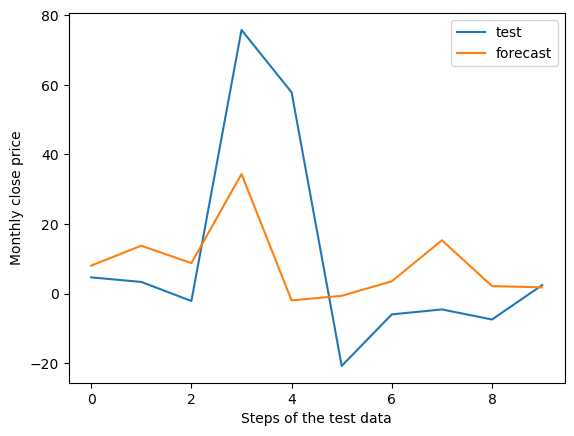

r2_score:  0.2435652077340138
rmse:  25.543903937672646
description:  count    113.000000
mean       2.917248
std       17.492586
min      -26.315789
25%       -7.469342
50%        0.423729
75%        8.928571
max       75.824176
Name: returns, dtype: float64


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=jaizbank_end_month_df['returns'].dropna()[:-10]
y_test=jaizbank_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,1,0), 
seasonal_order=(2,1,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', jaizbank_end_month_df.returns.dropna().describe())

RMSE is far greater but we will use the returns.
